# pSMAD_2024-08-21 — 02c_manual_bead_well_annotation

**Feeds:** ED Fig 2j, 2k

**Position in the chain:** run the numbered notebooks in order

Ported unchanged from the original analysis: outputs are as they ran, and no code
cell was edited. Paths appear as `<analysis-root>/...`.


# Manual Bead-Well Annotation And ROI JSON Build

## Notebook Scope

This notebook is adapted for dataset 2. It reads the 39-scene manifest written by `02b_auto_roi_from_dapi.ipynb`, opens the stitched scene images and cyst labels, lets you mark one or more bead-well centers per scene, and writes the manual annotation TSV plus ROI JSON outputs for downstream quantification.

## Setup

In [ ]:
# Requires ipympl for widget backend.
%matplotlib widget

import json
import os
from datetime import datetime, timezone
from pathlib import Path

import ipywidgets as widgets
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tifffile
from IPython import get_ipython
from IPython.display import display
from matplotlib.patches import Circle
from skimage import color, draw, measure

print("Matplotlib backend:", matplotlib.get_backend())

Matplotlib backend: module://ipympl.backend_nbagg


## Settings Notes

In [ ]:
# -------------------------------
# Project + run settings
# -------------------------------
ROOT = Path.cwd().resolve()
if not (ROOT / "scripts").exists() and (ROOT.parent / "scripts").exists():
    ROOT = ROOT.parent.resolve()

OUT_BASE_DIR = ROOT / "results/manual_bead_well_39locations"
OUT_SCENE_DIR = ROOT / "results/array_crops_39/scene_images"
OUT_LABEL_DIR = ROOT / "results/manual_bead_well_39locations/labels"
OUT_ROI_DIR = ROOT / "results/rois/manual_bead_well_39locations"
OUT_TABLE_DIR = ROOT / "results/tables"

SCENE_MANIFEST_TSV = OUT_TABLE_DIR / "scene_manifest_39locations.tsv"
BEAD_WELL_TSV = OUT_TABLE_DIR / "manual_bead_well_positions_39locations.tsv"
ROI_SUMMARY_TSV = OUT_TABLE_DIR / "manual_roi_summary_39locations.tsv"

BEAD_WELL_RADIUS_PX = (
    53.75  # approx 107.5 px diameter / 2; corrected after legacy 2x scale carryover
)
REQUIRE_39_SCENES = True
SCENE_OVERLAY_DOWNSAMPLE = 2
SCENE_OVERLAY_GRID_COLS = 7
OVERWRITE_ROI_JSON = True

for p in [OUT_BASE_DIR, OUT_SCENE_DIR, OUT_LABEL_DIR, OUT_ROI_DIR, OUT_TABLE_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("Project root:", ROOT)
print("Scene manifest TSV:", SCENE_MANIFEST_TSV)
print("Manual bead TSV:", BEAD_WELL_TSV)
print("ROI output dir:", OUT_ROI_DIR)

Project root: <analysis-root>/pSMAD_2024-08-21
Scene manifest TSV: <analysis-root>/pSMAD_2024-08-21/results/tables/scene_manifest_39locations.tsv
Manual bead TSV: <analysis-root>/pSMAD_2024-08-21/results/tables/manual_bead_well_positions_39locations.tsv
ROI output dir: <analysis-root>/pSMAD_2024-08-21/results/rois/manual_bead_well_39locations


## Helper Functions

In [ ]:
# -------------------------------
# Manual-annotation helper functions
# -------------------------------
BEAD_WELL_COLUMNS = [
    "source_file",
    "source_ome_path",
    "scene_index",
    "scene_name",
    "scene",
    "brightfield_image_path",
    "dapi_image_path",
    "psmad_image_path",
    "bead_image_path",
    "cyst_labels_path",
    "pixel_size_um",
    "n_cysts_detected",
    "expected_cysts",
    "annotation_status",
    "bead_well_index",
    "bead_well_x_px",
    "bead_well_y_px",
    "bead_well_radius_px",
    "annotator",
    "updated_at_utc",
]


MANIFEST_META_COLUMNS = [
    "source_file",
    "source_ome_path",
    "scene_index",
    "scene_name",
    "scene",
    "brightfield_image_path",
    "dapi_image_path",
    "psmad_image_path",
    "bead_image_path",
    "cyst_labels_path",
    "pixel_size_um",
    "n_cysts_detected",
    "expected_cysts",
]


def normalize_for_display(
    img: np.ndarray, p_lo: float = 2, p_hi: float = 99.8
) -> np.ndarray:
    """Percentile normalization for plotting only."""
    finite = img[np.isfinite(img)]
    lo, hi = np.percentile(finite, [p_lo, p_hi])
    den = max(1e-6, float(hi - lo))
    return np.clip((img - lo) / den, 0, 1)


def mask_to_polygon_xy(
    mask: np.ndarray, simplify_tolerance_px: float = 1.5, min_points: int = 8
) -> list[list[float]]:
    """Convert a binary mask to [x, y] polygon vertices."""
    contours = measure.find_contours(mask.astype(np.uint8), 0.5)
    if not contours:
        return []
    contour = max(contours, key=lambda c: c.shape[0])
    if simplify_tolerance_px > 0:
        contour = measure.approximate_polygon(contour, tolerance=simplify_tolerance_px)
    pts = [[float(col), float(row)] for row, col in contour]
    if len(pts) < min_points:
        return []
    return pts


def rel_to_root(path: Path) -> str:
    """Store paths relative to project root when possible."""
    try:
        return str(path.resolve().relative_to(ROOT.resolve()))
    except Exception:
        return str(path.resolve())


def scene_manifest_base(scene_manifest_df: pd.DataFrame) -> pd.DataFrame:
    base = scene_manifest_df.copy()
    for col in MANIFEST_META_COLUMNS:
        if col not in base.columns:
            base[col] = np.nan
    return base[MANIFEST_META_COLUMNS].sort_values("scene_index").reset_index(drop=True)


def _coerce_numeric(series: pd.Series) -> pd.Series:
    return pd.to_numeric(series, errors="coerce")


def _convert_legacy_single_bead_table(
    old_df: pd.DataFrame, scene_manifest_df: pd.DataFrame
) -> pd.DataFrame:
    base = scene_manifest_base(scene_manifest_df).set_index("scene_index", drop=False)
    old = old_df.copy()
    if "scene_index" not in old.columns:
        raise ValueError("Legacy bead table is missing 'scene_index'.")
    old = old.sort_values("scene_index").drop_duplicates("scene_index", keep="last")

    rows = []
    for rec in old.itertuples(index=False):
        scene_idx = int(getattr(rec, "scene_index"))
        if scene_idx not in base.index:
            continue
        meta = base.loc[scene_idx, MANIFEST_META_COLUMNS].to_dict()
        x = pd.to_numeric(
            pd.Series([getattr(rec, "bead_well_x_px", np.nan)]), errors="coerce"
        ).iloc[0]
        y = pd.to_numeric(
            pd.Series([getattr(rec, "bead_well_y_px", np.nan)]), errors="coerce"
        ).iloc[0]
        status = str(getattr(rec, "status", "unlabeled") or "unlabeled").strip().lower()
        annotator = str(getattr(rec, "annotator", "") or "")
        updated = str(getattr(rec, "updated_at_utc", "") or "")
        if np.isfinite(x) and np.isfinite(y):
            rows.append(
                {
                    **meta,
                    "annotation_status": "annotated",
                    "bead_well_index": 1,
                    "bead_well_x_px": float(x),
                    "bead_well_y_px": float(y),
                    "bead_well_radius_px": float(BEAD_WELL_RADIUS_PX),
                    "annotator": annotator,
                    "updated_at_utc": updated,
                }
            )
        elif status == "passed":
            rows.append(
                {
                    **meta,
                    "annotation_status": "no_bead",
                    "bead_well_index": 0,
                    "bead_well_x_px": np.nan,
                    "bead_well_y_px": np.nan,
                    "bead_well_radius_px": float(BEAD_WELL_RADIUS_PX),
                    "annotator": annotator,
                    "updated_at_utc": updated,
                }
            )
    out = pd.DataFrame(rows, columns=BEAD_WELL_COLUMNS)
    if out.empty:
        out = pd.DataFrame(columns=BEAD_WELL_COLUMNS)
    return out


def load_or_init_bead_table(
    table_path: Path, scene_manifest_df: pd.DataFrame, write_if_missing: bool = True
) -> pd.DataFrame:
    """Load bead annotation TSV in long form: one row per bead, or one no_bead row."""
    table_path = Path(table_path)
    base = scene_manifest_base(scene_manifest_df)

    if not table_path.exists():
        out = pd.DataFrame(columns=BEAD_WELL_COLUMNS)
        if write_if_missing:
            table_path.parent.mkdir(parents=True, exist_ok=True)
            out.to_csv(table_path, sep="\t", index=False)
        return out

    old = pd.read_csv(table_path, sep="\t")
    if len(old) == 0:
        out = pd.DataFrame(columns=BEAD_WELL_COLUMNS)
        if write_if_missing:
            table_path.parent.mkdir(parents=True, exist_ok=True)
            out.to_csv(table_path, sep="\t", index=False)
        return out

    if "annotation_status" not in old.columns or "bead_well_index" not in old.columns:
        out = _convert_legacy_single_bead_table(old, scene_manifest_df)
        if write_if_missing:
            table_path.parent.mkdir(parents=True, exist_ok=True)
            out.to_csv(table_path, sep="\t", index=False)
        return out

    out = old.copy()
    for col in BEAD_WELL_COLUMNS:
        if col not in out.columns:
            out[col] = np.nan

    out["scene_index"] = _coerce_numeric(out["scene_index"]).astype("Int64")
    out = out[out["scene_index"].notna()].copy()
    out["scene_index"] = out["scene_index"].astype(int)
    out["bead_well_index"] = (
        _coerce_numeric(out["bead_well_index"]).fillna(0).astype(int)
    )
    out["bead_well_x_px"] = _coerce_numeric(out["bead_well_x_px"])
    out["bead_well_y_px"] = _coerce_numeric(out["bead_well_y_px"])
    out["bead_well_radius_px"] = float(BEAD_WELL_RADIUS_PX)
    out["annotation_status"] = (
        out["annotation_status"].fillna("unlabeled").astype(str).str.strip().str.lower()
    )
    out["annotator"] = out["annotator"].fillna("").astype(str)
    out["updated_at_utc"] = out["updated_at_utc"].fillna("").astype(str)

    meta_lookup = base.set_index("scene_index", drop=False)
    keep_mask = out["scene_index"].isin(meta_lookup.index)
    out = out.loc[keep_mask].copy()
    for col in MANIFEST_META_COLUMNS:
        if col == "scene_index":
            continue
        out[col] = out["scene_index"].map(meta_lookup[col])

    out = (
        out[BEAD_WELL_COLUMNS]
        .sort_values(["scene_index", "annotation_status", "bead_well_index"])
        .reset_index(drop=True)
    )
    if write_if_missing:
        table_path.parent.mkdir(parents=True, exist_ok=True)
        out.to_csv(table_path, sep="\t", index=False)
    return out


def existing_state_for_scene(
    bead_well_df: pd.DataFrame, scene_idx: int
) -> tuple[list[tuple[float, float]], str | None]:
    if bead_well_df is None or bead_well_df.empty:
        return [], None
    sub = bead_well_df.loc[bead_well_df["scene_index"] == int(scene_idx)].copy()
    if sub.empty:
        return [], None
    statuses = set(sub["annotation_status"].astype(str).str.lower())
    if "no_bead" in statuses:
        return [], "no_bead"
    sub = sub[sub["annotation_status"].astype(str).str.lower() == "annotated"].copy()
    if sub.empty:
        return [], None
    sub["bead_well_index"] = (
        _coerce_numeric(sub["bead_well_index"]).fillna(0).astype(int)
    )
    sub["bead_well_x_px"] = _coerce_numeric(sub["bead_well_x_px"])
    sub["bead_well_y_px"] = _coerce_numeric(sub["bead_well_y_px"])
    sub = sub.sort_values("bead_well_index")
    points = []
    for rec in sub.itertuples(index=False):
        if not np.isfinite(rec.bead_well_x_px) or not np.isfinite(rec.bead_well_y_px):
            continue
        points.append((float(rec.bead_well_x_px), float(rec.bead_well_y_px)))
    if len(points) > 0:
        return points, "annotated"
    return [], None


def summarize_bead_annotations(
    scene_manifest_df: pd.DataFrame, bead_well_df: pd.DataFrame
) -> pd.DataFrame:
    base = scene_manifest_base(scene_manifest_df).copy()
    rows = []
    for rec in base.itertuples(index=False):
        scene_idx = int(rec.scene_index)
        points, status = existing_state_for_scene(bead_well_df, scene_idx)
        if status is None:
            status = "unlabeled"
        sub = bead_well_df.loc[bead_well_df["scene_index"] == scene_idx].copy()
        updated = ""
        if not sub.empty and "updated_at_utc" in sub.columns:
            vals = [str(v) for v in sub["updated_at_utc"].tolist() if str(v)]
            if vals:
                updated = max(vals)
        rows.append(
            {
                **{c: getattr(rec, c) for c in MANIFEST_META_COLUMNS},
                "annotation_status": status,
                "n_beads_annotated": int(len(points)),
                "updated_at_utc": updated,
            }
        )
    return pd.DataFrame(rows).sort_values("scene_index").reset_index(drop=True)


def replace_scene_bead_rows(
    table_path: Path,
    scene_row: pd.Series,
    points_xy: list[tuple[float, float]],
    annotation_status: str,
    annotator: str,
) -> pd.DataFrame:
    status = str(annotation_status).strip().lower()
    if status not in {"annotated", "no_bead", "unlabeled"}:
        raise ValueError(f"Unsupported annotation_status: {annotation_status!r}")
    if status == "annotated" and len(points_xy) == 0:
        raise ValueError("Annotated scene requires at least one bead point.")

    if table_path.exists() and table_path.stat().st_size > 0:
        df = pd.read_csv(table_path, sep="\t")
    else:
        df = pd.DataFrame(columns=BEAD_WELL_COLUMNS)
    if len(df) > 0 and (
        "annotation_status" not in df.columns or "bead_well_index" not in df.columns
    ):
        raise RuntimeError(
            "Existing bead TSV is still in the legacy single-bead format. "
            "Reload the notebook so it can be normalized before saving edits."
        )
    for col in BEAD_WELL_COLUMNS:
        if col not in df.columns:
            df[col] = np.nan

    scene_idx = int(scene_row["scene_index"])
    df = df.loc[
        _coerce_numeric(df["scene_index"]).fillna(-1).astype(int) != scene_idx
    ].copy()

    rows = []
    now = datetime.now(timezone.utc).isoformat(timespec="seconds")
    meta = {col: scene_row.get(col, np.nan) for col in MANIFEST_META_COLUMNS}
    if status == "no_bead":
        rows.append(
            {
                **meta,
                "annotation_status": "no_bead",
                "bead_well_index": 0,
                "bead_well_x_px": np.nan,
                "bead_well_y_px": np.nan,
                "bead_well_radius_px": float(BEAD_WELL_RADIUS_PX),
                "annotator": str(annotator or ""),
                "updated_at_utc": now,
            }
        )
    elif status == "annotated":
        for idx, (x, y) in enumerate(points_xy, start=1):
            rows.append(
                {
                    **meta,
                    "annotation_status": "annotated",
                    "bead_well_index": int(idx),
                    "bead_well_x_px": float(x),
                    "bead_well_y_px": float(y),
                    "bead_well_radius_px": float(BEAD_WELL_RADIUS_PX),
                    "annotator": str(annotator or ""),
                    "updated_at_utc": now,
                }
            )

    add_df = pd.DataFrame(rows, columns=BEAD_WELL_COLUMNS)
    out = (
        pd.concat([df[BEAD_WELL_COLUMNS], add_df], ignore_index=True)
        if len(add_df)
        else df[BEAD_WELL_COLUMNS].copy()
    )
    out["bead_well_radius_px"] = float(BEAD_WELL_RADIUS_PX)
    out = out.sort_values(
        ["scene_index", "annotation_status", "bead_well_index"]
    ).reset_index(drop=True)
    table_path.parent.mkdir(parents=True, exist_ok=True)
    out.to_csv(table_path, sep="\t", index=False)
    return out


def bead_points_lookup(bead_well_df: pd.DataFrame) -> dict[int, list[list[float]]]:
    lookup: dict[int, list[list[float]]] = {}
    if bead_well_df is None or bead_well_df.empty:
        return lookup
    for scene_idx in sorted(
        pd.to_numeric(bead_well_df["scene_index"], errors="coerce")
        .dropna()
        .astype(int)
        .unique()
    ):
        points, status = existing_state_for_scene(bead_well_df, int(scene_idx))
        if status == "annotated" and len(points) > 0:
            lookup[int(scene_idx)] = [[float(x), float(y)] for x, y in points]
    return lookup

## Load Scene Manifest

In [ ]:
# -------------------------------
# Load scene manifest written by notebook 02b
# -------------------------------
assert (
    SCENE_MANIFEST_TSV.exists()
), f"Missing scene manifest: {SCENE_MANIFEST_TSV}. Run 02b_auto_roi_from_dapi.ipynb first."

scene_manifest_df = (
    pd.read_csv(SCENE_MANIFEST_TSV, sep="	")
    .sort_values("scene_index")
    .reset_index(drop=True)
)

if REQUIRE_39_SCENES and len(scene_manifest_df) != 39:
    raise RuntimeError(
        f"Expected 39 scenes in {SCENE_MANIFEST_TSV.name}, found {len(scene_manifest_df)}."
    )

print("Scenes loaded from manifest:", len(scene_manifest_df))
print("Scene images dir:", OUT_SCENE_DIR)
print("Label dir:", OUT_LABEL_DIR)
display(
    scene_manifest_df[
        [
            "scene_index",
            "scene_name",
            "n_cysts_detected",
            "expected_cysts",
            "brightfield_image_path",
            "cyst_labels_path",
        ]
    ].head(10)
)

Scenes loaded from manifest: 39
Scene images dir: <analysis-root>/pSMAD_2024-08-21/results/array_crops_39/scene_images
Label dir: <analysis-root>/pSMAD_2024-08-21/results/manual_bead_well_39locations/labels


   scene_index scene_name  n_cysts_detected  expected_cysts  \
0            0    scene00                 6               6   
1            1    scene01                 4               4   
2            2    scene02                 5               5   
3            3    scene03                 4               4   
4            4    scene04                 6               6   
5            5    scene05                 5               5   
6            6    scene06                 7               7   
7            7    scene07                 7               7   
8            8    scene08                 6               6   
9            9    scene09                 5               5   

                              brightfield_image_path  \
0  results/array_crops_39/scene_images/scene00_bf...   
1  results/array_crops_39/scene_images/scene01_bf...   
2  results/array_crops_39/scene_images/scene02_bf...   
3  results/array_crops_39/scene_images/scene03_bf...   
4  results/array_crops_39/

## Manual Bead-Well Annotation Widget

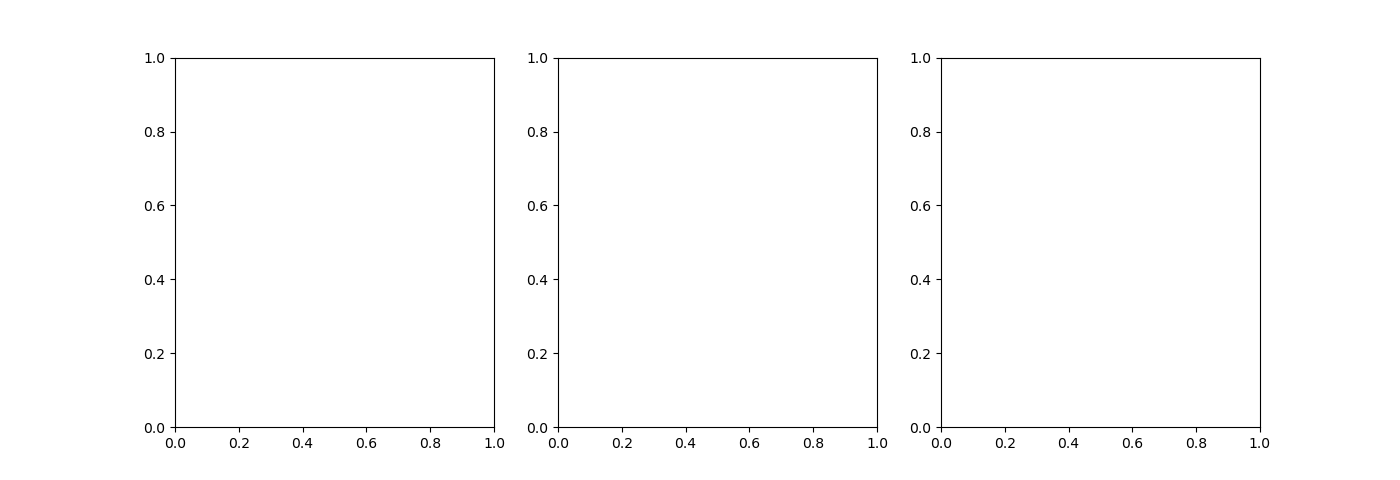

Annotation file: <analysis-root>/pSMAD_2024-08-21/results/tables/manual_bead_well_positions_39locations.tsv
Tip: after annotation, rerun the next cells to refresh coverage, build ROI JSON, and render final montage.


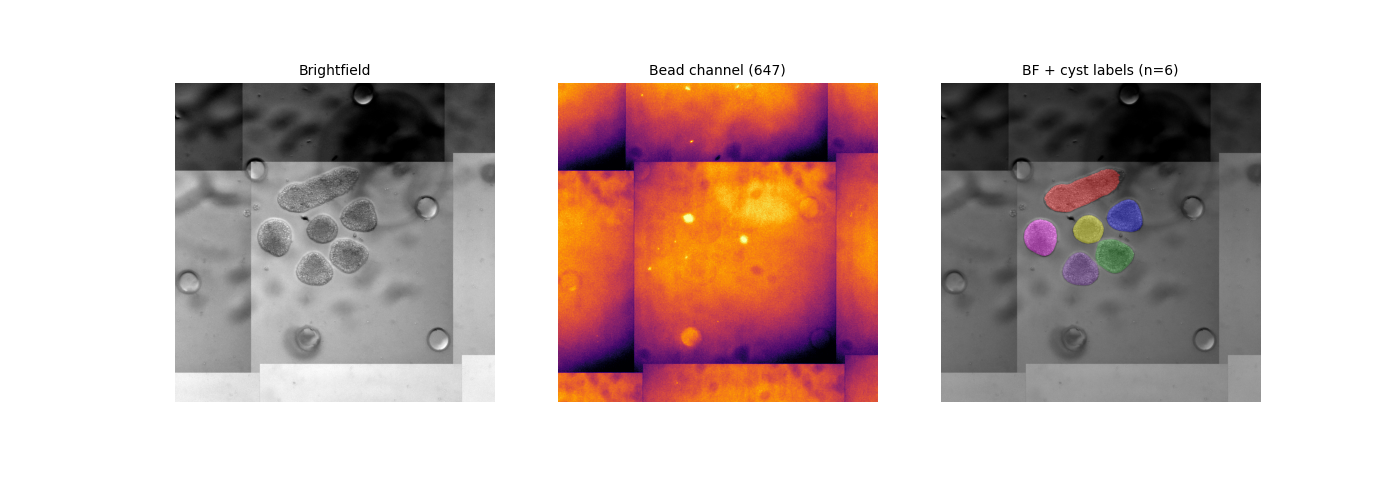

In [ ]:
class ManualBeadWellSession:
    """Multi-bead manual annotation UI backed by a long-form TSV."""

    def __init__(self, scene_manifest_df: pd.DataFrame, table_path: Path, root: Path):
        self.root = Path(root)
        self.table_path = Path(table_path)
        self.scene_manifest_df = scene_manifest_base(scene_manifest_df)
        self.df = load_or_init_bead_table(
            self.table_path, self.scene_manifest_df, write_if_missing=True
        )
        self.scene_indices = [
            int(x) for x in self.scene_manifest_df["scene_index"].tolist()
        ]
        self.current_pos = 0
        self.current_points_xy = []
        self.current_annotation_status = None  # "annotated", "no_bead", None
        self.undo_stack = []

        self.scene_slider = widgets.IntSlider(
            value=0,
            min=0,
            max=max(0, len(self.scene_indices) - 1),
            step=1,
            description="Scene idx",
            continuous_update=False,
        )
        self.prev_btn = widgets.Button(description="Prev", button_style="")
        self.pass_btn = widgets.Button(description="Pass", button_style="")
        self.save_next_btn = widgets.Button(
            description="Save Centers + Next", button_style="success"
        )
        self.no_bead_btn = widgets.Button(
            description="No Bead + Next", button_style="warning"
        )
        self.clear_no_bead_btn = widgets.Button(description="Clear No Bead")
        self.erase_all_btn = widgets.Button(description="Erase All")
        self.undo_btn = widgets.Button(description="Undo")

        self.status_html = widgets.HTML()
        self.hint_html = widgets.HTML()
        self.log_out = widgets.Output(
            layout={
                "border": "1px solid #ddd",
                "max_height": "160px",
                "overflow": "auto",
            }
        )

        self.fig, self.axes = plt.subplots(1, 3, figsize=(14, 4.8))
        self.fig.canvas.toolbar_visible = True
        self.fig.canvas.header_visible = False

        self.scene_slider.observe(self._on_slider_change, names="value")
        self.prev_btn.on_click(self._on_prev)
        self.pass_btn.on_click(self._on_pass)
        self.save_next_btn.on_click(self._on_save_next)
        self.no_bead_btn.on_click(self._on_no_bead_next)
        self.clear_no_bead_btn.on_click(self._on_clear_no_bead)
        self.erase_all_btn.on_click(self._on_erase_all)
        self.undo_btn.on_click(self._on_undo)

        self.fig.canvas.mpl_connect("button_press_event", self._on_click)

        self._load_scene_state()

    def _now_iso(self) -> str:
        return datetime.now(timezone.utc).isoformat(timespec="seconds")

    def _log(self, msg: str) -> None:
        with self.log_out:
            print(msg)

    def _scene_row(self):
        return self.scene_manifest_df.iloc[self.current_pos]

    def _load_scene_state(self) -> None:
        scene_idx = int(self._scene_row()["scene_index"])
        self.current_points_xy, self.current_annotation_status = (
            existing_state_for_scene(self.df, scene_idx)
        )
        self.undo_stack = []

    def _load_arrays(self, row):
        bf = tifffile.imread((self.root / row["brightfield_image_path"]).resolve())
        bead = tifffile.imread((self.root / row["bead_image_path"]).resolve())
        labels = tifffile.imread((self.root / row["cyst_labels_path"]).resolve())
        return np.asarray(bf), np.asarray(bead), np.asarray(labels).astype(np.int32)

    def _push_undo(self) -> None:
        self.undo_stack.append(
            (list(self.current_points_xy), self.current_annotation_status)
        )
        if len(self.undo_stack) > 100:
            self.undo_stack = self.undo_stack[-100:]

    def _clamp_point(
        self, x: float, y: float, shape_hw: tuple[int, int]
    ) -> tuple[float, float]:
        h, w = shape_hw
        return float(np.clip(x, 0, w - 1)), float(np.clip(y, 0, h - 1))

    def _draw_points(self) -> None:
        row = self._scene_row()
        radius = float(BEAD_WELL_RADIUS_PX)
        for idx, (x, y) in enumerate(self.current_points_xy, start=1):
            for ax in self.axes:
                circ = Circle(
                    (x, y),
                    radius=radius,
                    facecolor=(1.0, 0.0, 1.0, 0.12),
                    edgecolor=(1.0, 0.0, 1.0, 0.9),
                    linewidth=1.5,
                )
                ax.add_patch(circ)
                ax.scatter(
                    [x],
                    [y],
                    s=52,
                    c="white",
                    edgecolors="black",
                    linewidths=0.7,
                    marker="o",
                )
                ax.scatter([x], [y], s=68, c="magenta", linewidths=1.0, marker="+")
                ax.text(
                    x + 4.0,
                    y - 4.0,
                    str(idx),
                    color="magenta",
                    fontsize=8,
                    fontweight="bold",
                    bbox=dict(facecolor=(1, 1, 1, 0.65), edgecolor="none", pad=0.6),
                )
        if self.current_annotation_status == "no_bead":
            for ax in self.axes:
                ax.text(
                    0.02,
                    0.98,
                    "NO BEAD",
                    transform=ax.transAxes,
                    ha="left",
                    va="top",
                    fontsize=10,
                    fontweight="bold",
                    color="yellow",
                    bbox=dict(facecolor="black", alpha=0.5, edgecolor="yellow"),
                )

    def _refresh_headers(self) -> None:
        summary_df = summarize_bead_annotations(self.scene_manifest_df, self.df)
        n_total = int(len(summary_df))
        n_annot = int((summary_df["annotation_status"] == "annotated").sum())
        n_no_bead = int((summary_df["annotation_status"] == "no_bead").sum())
        n_unlabeled = int((summary_df["annotation_status"] == "unlabeled").sum())
        n_beads_total = int(summary_df["n_beads_annotated"].sum())

        row = self._scene_row()
        scene_idx = int(row["scene_index"])
        scene_name = str(row["scene_name"])
        status = (
            self.current_annotation_status
            if self.current_annotation_status is not None
            else "unlabeled"
        )

        self.status_html.value = (
            f"<b>Coverage</b>: annotated={n_annot}/{n_total} | no_bead={n_no_bead} | "
            f"unlabeled={n_unlabeled} | total saved beads={n_beads_total}"
        )
        self.hint_html.value = (
            f"<b>Current</b>: scene {scene_idx:02d} ({scene_name}) | status={status} | "
            f"local beads={len(self.current_points_xy)}. Left-click any panel to add one or more bead-well centers, then Save Centers + Next."
        )

    def _render_scene(self) -> None:
        row = self._scene_row()
        bf, bead, labels = self._load_arrays(row)

        bf_disp = normalize_for_display(bf)
        bead_disp = normalize_for_display(bead)
        overlay = color.label2rgb(labels, image=bf_disp, bg_label=0, alpha=0.35)

        titles = [
            "Brightfield",
            "Bead channel (647)",
            f"BF + cyst labels (n={int(row['n_cysts_detected'])})",
        ]

        for ax in self.axes:
            ax.clear()

        self.axes[0].imshow(bf_disp, cmap="gray")
        self.axes[1].imshow(bead_disp, cmap="inferno")
        self.axes[2].imshow(np.clip(overlay, 0.0, 1.0))

        for ax, title in zip(self.axes, titles, strict=True):
            ax.set_title(title, fontsize=10)
            ax.axis("off")

        self._draw_points()
        self._refresh_headers()
        self.fig.canvas.draw_idle()

    def _set_scene_pos(self, new_pos: int) -> None:
        new_pos = int(np.clip(new_pos, 0, len(self.scene_indices) - 1))
        self.current_pos = new_pos
        self.scene_slider.value = new_pos
        self._load_scene_state()
        self._render_scene()

    def _on_slider_change(self, change):
        new_pos = int(change["new"])
        if new_pos == self.current_pos:
            return
        self.current_pos = new_pos
        self._load_scene_state()
        self._render_scene()

    def _on_click(self, event):
        if event.inaxes not in set(self.axes):
            return
        if event.button != 1:
            return
        if event.xdata is None or event.ydata is None:
            return

        row = self._scene_row()
        bf, _, _ = self._load_arrays(row)
        x, y = self._clamp_point(float(event.xdata), float(event.ydata), bf.shape[:2])
        self._push_undo()
        self.current_points_xy.append((x, y))
        self.current_annotation_status = "annotated"
        self._log(
            f"Scene {int(row['scene_index']):02d}: added bead #{len(self.current_points_xy)} at ({x:.1f}, {y:.1f})"
        )
        self._render_scene()

    def _save_current_rows(self, status: str) -> None:
        scene_row = self._scene_row()
        annotator = os.environ.get("USER", "")
        self.df = replace_scene_bead_rows(
            table_path=self.table_path,
            scene_row=scene_row,
            points_xy=list(self.current_points_xy),
            annotation_status=status,
            annotator=annotator,
        )
        self._load_scene_state()

    def _advance_after_save(self, end_msg: str) -> None:
        if self.current_pos < len(self.scene_indices) - 1:
            self._set_scene_pos(self.current_pos + 1)
        else:
            self._render_scene()
            self._log(end_msg)

    def _on_prev(self, _):
        self._set_scene_pos(self.current_pos - 1)

    def _on_pass(self, _):
        row = self._scene_row()
        self._log(
            f"Passed scene {int(row['scene_index']):02d} without changing saved annotation."
        )
        if self.current_pos < len(self.scene_indices) - 1:
            self._set_scene_pos(self.current_pos + 1)
        else:
            self._render_scene()

    def _on_save_next(self, _):
        if len(self.current_points_xy) == 0:
            self._log(
                "No bead centers set. Add centroid(s) first, or choose No Bead + Next."
            )
            return
        row = self._scene_row()
        self._save_current_rows(status="annotated")
        self._log(
            f"Saved scene {int(row['scene_index']):02d} with {len(self.current_points_xy)} bead center(s)."
        )
        self._advance_after_save(end_msg="Saved final scene.")

    def _on_no_bead_next(self, _):
        self._push_undo()
        self.current_points_xy = []
        self.current_annotation_status = "no_bead"
        row = self._scene_row()
        self._save_current_rows(status="no_bead")
        self._log(f"Saved scene {int(row['scene_index']):02d} as no_bead.")
        self._advance_after_save(end_msg="Saved final scene as no_bead.")

    def _on_clear_no_bead(self, _):
        if self.current_annotation_status != "no_bead":
            self._log("Current local state is not no_bead.")
            return
        self._push_undo()
        self.current_annotation_status = None
        self._render_scene()
        self._log("Cleared local no_bead flag.")

    def _on_erase_all(self, _):
        if len(self.current_points_xy) == 0:
            self._log("No bead centers to erase.")
            return
        self._push_undo()
        self.current_points_xy = []
        if self.current_annotation_status == "annotated":
            self.current_annotation_status = None
        self._render_scene()
        self._log("Erased all local bead centers. Use Undo to restore.")

    def _on_undo(self, _):
        if not self.undo_stack:
            self._log("Nothing to undo.")
            return
        points_xy, status = self.undo_stack.pop()
        self.current_points_xy = list(points_xy)
        self.current_annotation_status = status
        self._render_scene()
        self._log("Undo applied.")

    def render(self):
        controls = widgets.HBox(
            [
                self.prev_btn,
                self.pass_btn,
                self.save_next_btn,
                self.no_bead_btn,
                self.clear_no_bead_btn,
                self.erase_all_btn,
                self.undo_btn,
            ]
        )
        box = widgets.VBox(
            [
                self.scene_slider,
                controls,
                self.status_html,
                self.hint_html,
                self.log_out,
            ]
        )
        display(box)
        display(self.fig.canvas)
        self._render_scene()


manual_bead_session = ManualBeadWellSession(
    scene_manifest_df=scene_manifest_df,
    table_path=BEAD_WELL_TSV,
    root=ROOT,
)
manual_bead_session.render()

print("Annotation file:", BEAD_WELL_TSV)
print(
    "Tip: after annotation, rerun the next cells to refresh coverage, build ROI JSON, and render final montage."
)

## Annotation Coverage Review

In [ ]:
# -------------------------------
# Coverage check after manual annotation
# -------------------------------
bead_well_df = load_or_init_bead_table(
    BEAD_WELL_TSV, scene_manifest_df, write_if_missing=True
)
coverage_df = summarize_bead_annotations(scene_manifest_df, bead_well_df)

n_total = int(len(coverage_df))
n_annot = int((coverage_df["annotation_status"] == "annotated").sum())
n_no_bead = int((coverage_df["annotation_status"] == "no_bead").sum())
n_unlabeled = int((coverage_df["annotation_status"] == "unlabeled").sum())
n_beads_total = int(coverage_df["n_beads_annotated"].sum())

print(f"Annotated scenes: {n_annot}/{n_total}")
print(f"No-bead scenes:   {n_no_bead}")
print(f"Unlabeled scenes: {n_unlabeled}")
print(f"Saved bead centers total: {n_beads_total}")

display(
    coverage_df[
        [
            "scene_index",
            "scene_name",
            "n_cysts_detected",
            "expected_cysts",
            "annotation_status",
            "n_beads_annotated",
            "updated_at_utc",
        ]
    ]
)

Annotated scenes: 34/39
No-bead scenes:   5
Unlabeled scenes: 0
Saved bead centers total: 77


    scene_index scene_name  n_cysts_detected  expected_cysts  \
0             0    scene00                 6               6   
1             1    scene01                 4               4   
2             2    scene02                 5               5   
3             3    scene03                 4               4   
4             4    scene04                 6               6   
5             5    scene05                 5               5   
6             6    scene06                 7               7   
7             7    scene07                 7               7   
8             8    scene08                 6               6   
9             9    scene09                 5               5   
10           10    scene10                 7               7   
11           11    scene11                 4               4   
12           12    scene12                 6               6   
13           13    scene13                 7               7   
14           14    scene14              

## Save Stage Outputs

In [ ]:
# -------------------------------
# Build ROI JSON from (cyst polygons + manual bead-well centroids)
# -------------------------------
bead_well_df = load_or_init_bead_table(
    BEAD_WELL_TSV, scene_manifest_df, write_if_missing=True
)
coverage_df = summarize_bead_annotations(scene_manifest_df, bead_well_df)
annot_df = (
    coverage_df.loc[coverage_df["annotation_status"] == "annotated"]
    .copy()
    .sort_values("scene_index")
)
bead_lookup = bead_points_lookup(bead_well_df)

if OVERWRITE_ROI_JSON:
    for p in OUT_ROI_DIR.glob("manual_s*_cyst_*.json"):
        p.unlink()

roi_summary_rows = []
n_json_written = 0

for _, row in annot_df.iterrows():
    scene_idx = int(row["scene_index"])
    bead_points = bead_lookup.get(scene_idx, [])
    if len(bead_points) == 0:
        continue

    pixel_um = float(row["pixel_size_um"])
    labels_path = (ROOT / row["cyst_labels_path"]).resolve()
    labels = tifffile.imread(labels_path).astype(np.int32)
    props = measure.regionprops(labels)

    single_bead_xy = bead_points[0] if len(bead_points) == 1 else None
    single_bead_x = float(single_bead_xy[0]) if single_bead_xy is not None else np.nan
    single_bead_y = float(single_bead_xy[1]) if single_bead_xy is not None else np.nan

    for i, region in enumerate(props, start=1):
        mask = labels == int(region.label)
        poly = mask_to_polygon_xy(mask, simplify_tolerance_px=1.5)
        if len(poly) < 3:
            continue

        cyst_id = f"manual_s{scene_idx:02d}_cyst_{i:04d}"
        rec = {
            "cyst_id": cyst_id,
            "source_file": str(row["source_file"]),
            "scene": str(row["scene"]),
            "scene_index": int(scene_idx),
            "pixel_size_um": float(pixel_um),
            "psmad_image_path": str(row["psmad_image_path"]),
            "dapi_image_path": str(row["dapi_image_path"]),
            "bead_image_path": str(row["bead_image_path"]),
            "n_beads_annotated": int(len(bead_points)),
            "bead_xys_px": [[float(x), float(y)] for x, y in bead_points],
            "bead_xy_px": (
                [float(single_bead_xy[0]), float(single_bead_xy[1])]
                if single_bead_xy is not None
                else None
            ),
            "polygon_xy_px": poly,
            "roi_method": "auto_cyst_manual_bead_well_notebook",
            "roi_area_px": int(region.area),
            "roi_centroid_xy_px": [
                float(region.centroid[1]),
                float(region.centroid[0]),
            ],
        }

        out_json = OUT_ROI_DIR / f"{cyst_id}.json"
        out_json.write_text(json.dumps(rec, indent=2), encoding="utf-8")
        n_json_written += 1

        roi_summary_rows.append(
            {
                "cyst_id": cyst_id,
                "source_file": str(row["source_file"]),
                "scene": str(row["scene"]),
                "scene_index": int(scene_idx),
                "roi_area_px": int(region.area),
                "centroid_x_px": float(region.centroid[1]),
                "centroid_y_px": float(region.centroid[0]),
                "n_beads_annotated": int(len(bead_points)),
                "bead_well_x_px": single_bead_x,
                "bead_well_y_px": single_bead_y,
                "bead_xys_px_json": json.dumps(bead_points),
                "dapi_image_path": str(row["dapi_image_path"]),
                "psmad_image_path": str(row["psmad_image_path"]),
                "roi_json_path": rel_to_root(out_json),
            }
        )

roi_summary_columns = [
    "cyst_id",
    "source_file",
    "scene",
    "scene_index",
    "roi_area_px",
    "centroid_x_px",
    "centroid_y_px",
    "n_beads_annotated",
    "bead_well_x_px",
    "bead_well_y_px",
    "bead_xys_px_json",
    "dapi_image_path",
    "psmad_image_path",
    "roi_json_path",
]

roi_summary_df = pd.DataFrame(roi_summary_rows, columns=roi_summary_columns)
roi_summary_df.to_csv(ROI_SUMMARY_TSV, sep="\t", index=False)

print("Bead position TSV:", BEAD_WELL_TSV)
print("ROI summary TSV:", ROI_SUMMARY_TSV)
print("ROI JSON directory:", OUT_ROI_DIR)
print("Scenes with manual bead coordinates:", len(annot_df))
print("ROI JSON files written:", n_json_written)

display(roi_summary_df.head(20) if len(roi_summary_df) else roi_summary_df)

Bead position TSV: <analysis-root>/pSMAD_2024-08-21/results/tables/manual_bead_well_positions_39locations.tsv
ROI summary TSV: <analysis-root>/pSMAD_2024-08-21/results/tables/manual_roi_summary_39locations.tsv
ROI JSON directory: <analysis-root>/pSMAD_2024-08-21/results/rois/manual_bead_well_39locations
Scenes with manual bead coordinates: 34
ROI JSON files written: 225


                 cyst_id       source_file    scene  scene_index  roi_area_px  \
0   manual_s00_cyst_0001  scene00_dapi.tif  scene00            0        39555   
1   manual_s00_cyst_0002  scene00_dapi.tif  scene00            0        19396   
2   manual_s00_cyst_0003  scene00_dapi.tif  scene00            0        14590   
3   manual_s00_cyst_0004  scene00_dapi.tif  scene00            0        20234   
4   manual_s00_cyst_0005  scene00_dapi.tif  scene00            0        21371   
5   manual_s00_cyst_0006  scene00_dapi.tif  scene00            0        19700   
6   manual_s02_cyst_0001  scene02_dapi.tif  scene02            2        19714   
7   manual_s02_cyst_0002  scene02_dapi.tif  scene02            2        57614   
8   manual_s02_cyst_0003  scene02_dapi.tif  scene02            2        16384   
9   manual_s02_cyst_0004  scene02_dapi.tif  scene02            2        22266   
10  manual_s02_cyst_0005  scene02_dapi.tif  scene02            2        15592   
11  manual_s03_cyst_0001  sc

## Final Preview

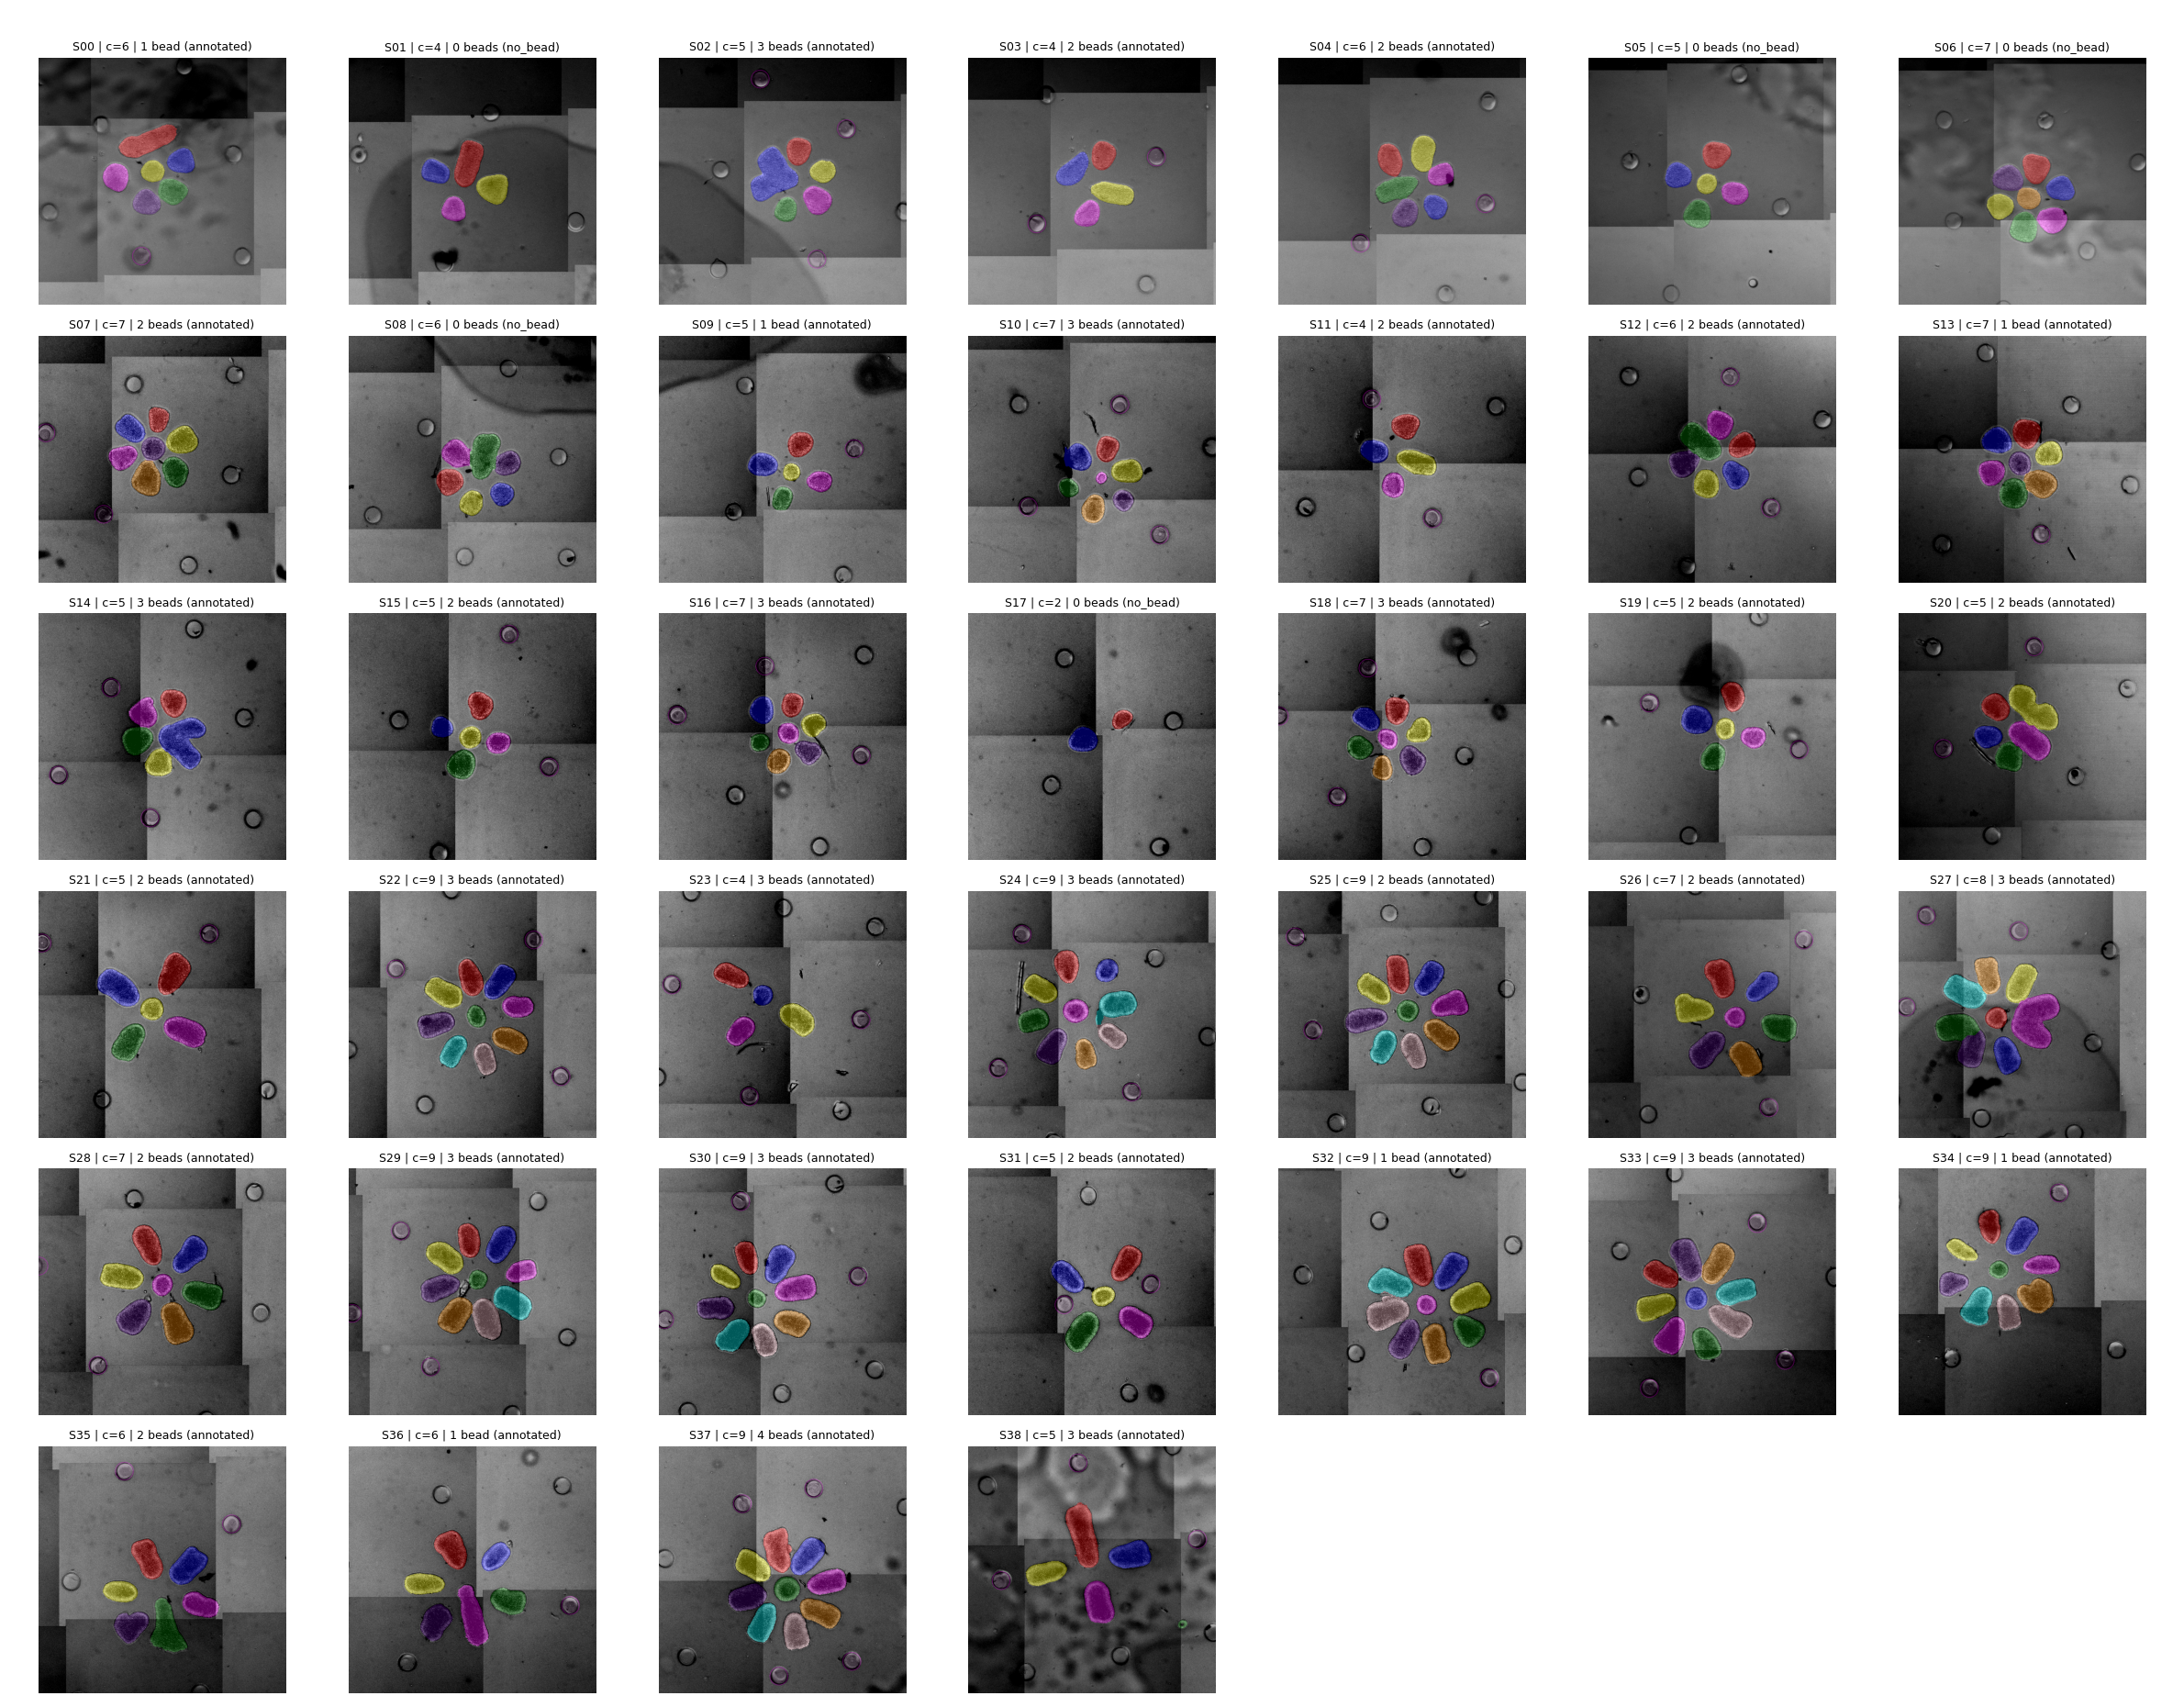

In [ ]:
# -------------------------------
# Final all-scene preview: cyst labels + manual bead-well marker
# -------------------------------
bead_well_df = load_or_init_bead_table(
    BEAD_WELL_TSV, scene_manifest_df, write_if_missing=True
)
coverage_df = summarize_bead_annotations(scene_manifest_df, bead_well_df)
bead_lookup = bead_points_lookup(bead_well_df)

final_items = []
for row in coverage_df.itertuples(index=False):
    scene_idx = int(row.scene_index)
    bf = tifffile.imread((ROOT / row.brightfield_image_path).resolve())
    labels = tifffile.imread((ROOT / row.cyst_labels_path).resolve()).astype(np.int32)

    rgb = color.label2rgb(
        labels, image=normalize_for_display(bf), bg_label=0, alpha=0.35
    )
    rgb = np.clip(rgb, 0.0, 1.0)

    points = bead_lookup.get(scene_idx, [])
    has_bead = len(points) > 0
    status = str(row.annotation_status)
    r = float(BEAD_WELL_RADIUS_PX)

    for x, y in points:
        rr_fill, cc_fill = draw.disk(
            (float(y), float(x)), radius=max(4.0, r), shape=rgb.shape[:2]
        )
        rgb[rr_fill, cc_fill] = 0.96 * rgb[rr_fill, cc_fill] + 0.04 * np.array(
            [1.0, 0.0, 1.0], dtype=np.float32
        )

        rr_o, cc_o = draw.disk(
            (float(y), float(x)), radius=max(4.0, r + 2.0), shape=rgb.shape[:2]
        )
        rr_i, cc_i = draw.disk(
            (float(y), float(x)), radius=max(2.0, r - 2.0), shape=rgb.shape[:2]
        )
        ring_outer = np.zeros(rgb.shape[:2], dtype=bool)
        ring_inner = np.zeros(rgb.shape[:2], dtype=bool)
        ring_outer[rr_o, cc_o] = True
        ring_inner[rr_i, cc_i] = True
        ring_mask = ring_outer & (~ring_inner)
        rgb[ring_mask] = 0.65 * rgb[ring_mask] + 0.35 * np.array(
            [1.0, 0.0, 1.0], dtype=np.float32
        )

        rr_c, cc_c = draw.disk((float(y), float(x)), radius=2.5, shape=rgb.shape[:2])
        rgb[rr_c, cc_c] = 0.82 * rgb[rr_c, cc_c] + 0.18 * np.array(
            [1.0, 1.0, 1.0], dtype=np.float32
        )

    ds = max(1, int(SCENE_OVERLAY_DOWNSAMPLE))
    preview = (np.clip(rgb[::ds, ::ds], 0.0, 1.0) * 255).astype(np.uint8)
    final_items.append(
        {
            "scene_index": scene_idx,
            "n_cysts": int(row.n_cysts_detected),
            "status": status,
            "n_beads": int(len(points)),
            "has_bead": bool(has_bead),
            "image": preview,
        }
    )

final_items = sorted(final_items, key=lambda d: d["scene_index"])
n = len(final_items)
ncols = max(1, int(SCENE_OVERLAY_GRID_COLS))
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(3.4 * ncols, 3.1 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, item in zip(axes, final_items):
    ax.imshow(item["image"])
    bead_tag = (
        f"{item['n_beads']} bead"
        if item["n_beads"] == 1
        else f"{item['n_beads']} beads"
    )
    ax.set_title(
        f"S{item['scene_index']:02d} | c={item['n_cysts']} | {bead_tag} ({item['status']})",
        fontsize=9,
    )
    ax.axis("off")

for ax in axes[len(final_items) :]:
    ax.axis("off")

fig.suptitle(
    "Final preview: BF + cyst labels + manual bead-well markers", y=1.01, fontsize=12
)
plt.tight_layout()
plt.show()